In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv("NIFTY50.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

data = df[['Close']]
data.dropna(inplace=True)

print(data.head())


            Close
Date             
2009-03-02  43.17
2009-03-03  43.89
2009-03-04  42.52
2009-03-05  41.49
2009-03-06  38.16


/var/folders/z4/58kf2rh54s395f0pkgk591q00000gn/T/ipykernel_1499/3643600502.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


In [4]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 60

X, y = create_sequences(scaled_data, WINDOW_SIZE)

X = X.reshape(X.shape[0], X.shape[1], 1)


In [5]:
train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [6]:
model = Sequential()

# CNN layer – feature extraction
model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(MaxPooling1D(pool_size=2))


model.add(LSTM(50))

model.add(Dropout(0.2))


model.add(Dense(1))


/Users/krish/stock_ml/venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,307 (91.04 KB)

 Trainable params: 23,307 (91.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - val_loss: 0.0041
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.9561e-04 - val_loss: 0.0030
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.8464e-04 - val_loss: 0.0022
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6661e-04 - val_loss: 0.0018
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1871e-04 - val_loss: 0.0016
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4025e-04 - val_loss: 0.0012
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.1912e-04 - val_loss: 0.0010
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8386e-04 - val_loss: 9.8698e-04
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.7758e-04 - val_loss: 9.2024e-04
Epoch 10/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.7473e-04 - val_loss: 9.3220e-04
Epoch 11/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.5478e-04 - val_loss: 7.9993e-04
Epoch 12/20
75/75 

In [9]:
predicted_prices = model.predict(X_test)

predicted_prices = scaler.inverse_transform(predicted_prices)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [10]:
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)
r2 = r2_score(actual_prices, predicted_prices)
mse = mean_squared_error(actual_prices, predicted_prices)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

MSE: 5.671973248780454
RMSE: 2.38159048721237
MAE: 1.2854252564847568
R² Score: 0.9432757764159695


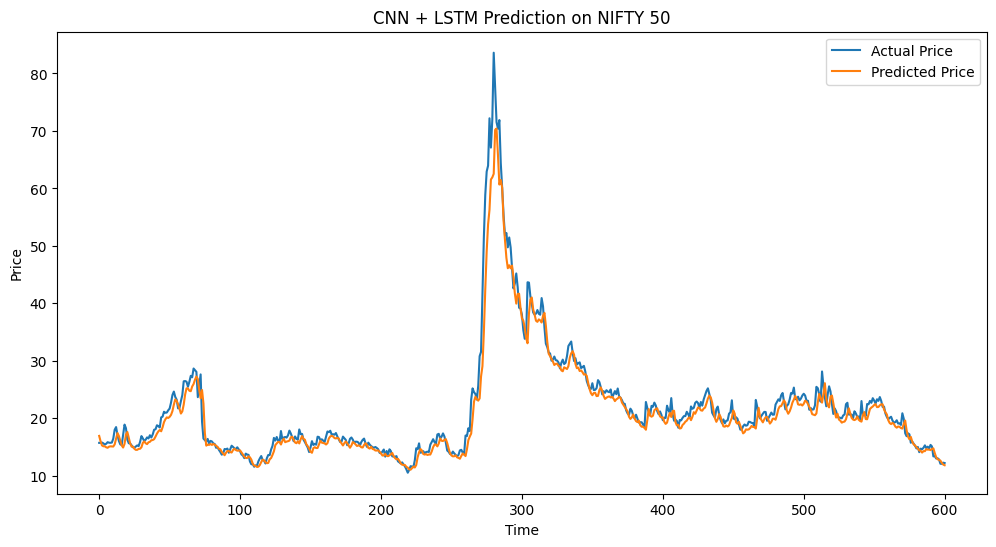

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label="Actual Price")
plt.plot(predicted_prices, label="Predicted Price")
plt.title("CNN + LSTM Prediction on NIFTY 50")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


In [12]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1, 60, 1)

next_day_scaled = model.predict(last_60_days)
next_day_price = scaler.inverse_transform(next_day_scaled)

print("Predicted NIFTY 50 closing price for next day:")
print(next_day_price[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predicted NIFTY 50 closing price for next day:
12.010597
